# Reproduce the paper's diagnostic figures — **emulator-free**

This notebook regenerates the four diagnostic figures that the paper turns on,
reading **only the committed grad-faith sidecars** (`grad_faith_*.csv` +
`pareto_*.csv`). **No emulator (GP / PySR / Julia) is loaded** — every number is
cached in the CSV sidecars next to each Pareto front.

The paper is a **derivative-faithfulness diagnostic**: *where, why, and how badly
per-parameter 1D symbolic regression (PySR) fails as a Fisher emulator for the
Lyman-α P1D, and what a Sobolev derivative-matching loss does and does not fix.*
See `docs/PARETO_FAITHFULNESS_WALKTHROUGH.md` and `HANDOFF.md` for the science.

> **Scope caveat (GP-as-oracle).** The whole diagnostic treats the multi-fidelity
> GP emulator as ground truth for both values and slopes ∂P/∂θ. It measures whether
> a PySR equation reproduces the **GP's** derivatives, not the true simulation
> derivatives. The earlier σ_PySR/σ_GP forecast claim is deliberately dropped: the
> 4-agent review (2026-06-05) showed σ_perfect_1D ≡ σ_GP is forced by construction,
> so that ladder tested a Jacobian, not an emulator. The four figures below are
> exactly what the GP-as-oracle setup *can* legitimately support, plotted with **no
> GP-slice fallback** (a parameter with no faithful equation simply shows up all-red).

## The four figures (all emulator-free)

| # | figure | what it shows | which sidecars feed it | needs GP? |
|---|--------|---------------|------------------------|:---------:|
| 1 | `pareto_faithfulness` | 11-panel grid, value MSE (height) vs grad_err (color), gate rings + ns Mirage arrow | `single_z_stage6_log` (value@20), `single_z_stage9` (Sobolev@20), `decider_budget_z3.6` (value@budget, ns only) | **no** |
| 2 | `faithfulness_scorecard` | per-parameter value-optimal grad_err, value-loss ● vs Sobolev ■, sorted; gate dashed | `single_z_stage6_log`, `single_z_stage9` | **no** |
| 3 | `ns_budget_panel` | ns budget control: budget (▲) reaches lowest value error but stays red; Sobolev (■) clears the gate | `single_z_stage6_log`, `single_z_stage9`, `decider_budget_z3.6` (ns) | **no** |
| 4 | `crossz_faithfulness` | Sobolev best-loss grad_err across z = 2.6 / 3.6 / 4.2; taxonomy is **not** redshift-uniform | `single_z_z2.6_sobolev`, `single_z_stage9`, `single_z_z4.2_sobolev` | **no** |

**None of the four figures needs the GP.** The only emulator-grounded quantities
(`grad_err`, `value_mse`) were computed once and committed to the sidecars.

## 0. Setup — put `src/` on the path and locate the inputs

Only `src/` is needed (this notebook is emulator-free; the upstream
`lya_emulator_full` clone, GP basedir, and Julia/PySR env vars are **not**
required). We resolve the repo root from this notebook's location so the relative
`results/...` sidecar paths in `scripts/make_diagnostic_figs.py` work regardless
of the current working directory.

In [1]:
import sys
from pathlib import Path

# Repo root = parent of this notebooks/ dir. Fall back to cwd if __file__-less.
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
REPO_ROOT = HERE if (HERE / "src").exists() else HERE.parent
assert (REPO_ROOT / "src" / "priya_forecast").exists(), f"src not found under {REPO_ROOT}"

SRC = str(REPO_ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# scripts/make_diagnostic_figs.py uses relative 'results/...' paths -> run from repo root.
import os
os.chdir(REPO_ROOT)

import matplotlib
matplotlib.use("Agg")          # headless; figures are saved + shown inline below
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

from priya_forecast.parameters import PARAM_NAMES
from priya_forecast.grad_faith_io import read_grad_faith_sidecar
from priya_forecast.pareto_diag import load_front, render_grid, GATE_TOL

print("repo root :", REPO_ROOT)
print("params    :", PARAM_NAMES)
print("gate tol  :", GATE_TOL)
print("emulator  : NOT loaded (no GPy / PySR / Julia imported)")

repo root : /home/mfho/lya1d_priya_forecast
params    : ('dtau0', 'tau0', 'ns', 'Ap', 'herei', 'heref', 'alphaq', 'hub', 'omegamh2', 'hireionz', 'bhfeedback')
gate tol  : 0.25
emulator  : NOT loaded (no GPy / PySR / Julia imported)


### Sidecar source directories

These mirror the constants at the top of `scripts/make_diagnostic_figs.py`. Each
holds one `grad_faith_<param>.csv` (and `pareto_<param>.csv`) per parameter, at
**single-z z = 3.6** on the real KODIAQ-SQUAD covariance:

- `VALUE`  — value-loss target, maxsize 20 (`single_z_stage6_log`)
- `SOBOLEV` — Sobolev derivative loss λ=5, maxsize 20 (`single_z_stage9`)
- `BUDGET` — value-loss at certified maxsize ≈ 35 (`decider_budget_z3.6`), **ns only**

The cross-z figure additionally uses the z = 2.6 / 4.2 Sobolev refits.

In [ ]:
VALUE   = "results/single_z_stage6_log/refit/z3.6"
SOBOLEV = "results/single_z_stage9/refit/z3.6"
BUDGET  = "results/decider_budget_z3.6/refit/z3.6"

OUT = Path("results/_repro_scratch")  # scratch: re-running does NOT touch the
# committed figures. To refresh those, run: python scripts/make_diagnostic_figs.py
# --out-dir results/single_z_stage_pareto_diag
OUT.mkdir(parents=True, exist_ok=True)

# Sanity-check the sidecars exist before plotting (emulator-free smoke test).
def _check(d, params):
    miss = [p for p in params if not (REPO_ROOT / d / f"grad_faith_{p}.csv").exists()]
    return miss

miss_v = _check(VALUE, PARAM_NAMES)
miss_s = _check(SOBOLEV, PARAM_NAMES)
miss_b = _check(BUDGET, ["ns"])
assert not miss_v, f"missing value sidecars: {miss_v}"
assert not miss_s, f"missing Sobolev sidecars: {miss_s}"
assert not miss_b, f"missing budget sidecars: {miss_b}"
print("all required sidecars present.")
print("VALUE  ->", VALUE)
print("SOBOLEV->", SOBOLEV)
print("BUDGET ->", BUDGET, "(ns only)")


def bestloss(d, p, col="grad_err"):
    # grad_err (or any col) of the lowest-PySR-loss candidate on a front.
    df = read_grad_faith_sidecar(f"{d}/grad_faith_{p}.csv").sort_values("Loss")
    return float(df.iloc[0][col])

## Figure 1 — `pareto_faithfulness` (the central instrument)

**One panel per parameter** (11 PRIYA parameters), z = 3.6.

- **x = complexity** (PySR equation node count).
- **y = `value_mse`** (log scale) = `mean over (θ,k) of (logP_eq − logP_GP)²` on the
  HF θ-grid — a *common, cross-objective-comparable* value loss. (We deliberately do
  **not** plot the raw PySR `Loss` column: Sobolev's loss is `MSE + λ·‖∂eq − ∂GP‖²`,
  numerically larger by construction, which would make it look like it "fits values
  worse" for free.)
- **Marker shape** = series: `value@20` ●, `Sobolev@20` ■, `value@budget` ▲ (ns panel only).
- **Marker color = `grad_err`** = `median_k |∂P_eq/∂θ ÷ ∂P_GP/∂θ − 1|` at fid over
  non-negligible k-bins — the **same metric the production derivative gate uses**.
  Green ≤ 0.25 (faithful) → red ≫ 0.25 (the *Fisher's Mirage*: right value, wrong
  slope). A **bold black ring** marks markers that clear the 0.25 gate.

**The Mirage made visible:** a marker that is *low* (good value) but *red* (bad
slope) is the failure mode — and Fisher sees only the slope. The annotated arrow on
the **ns** panel points at the lowest-value-error candidate that still fails the gate.

> Note on metric space: `grad_err` differences the **linear/raw P** prediction
> (`∂P_F/∂θ`), the Fisher-consistent quantity; `value_mse` is in log-P space. Both
> are emulator-only and committed to the sidecars.

**Feeds:** `VALUE`, `SOBOLEV` (all 11 params) + `BUDGET` (ns panel). Emulator-free.

In [3]:
# Build the per-parameter front bundle (replicates make_diagnostic_figs.py).
fronts = {}
for p in PARAM_NAMES:
    rows = [
        {"front": load_front(f"{VALUE}/pareto_{p}.csv",   f"{VALUE}/grad_faith_{p}.csv"),
         "label": "value@20",   "marker": "o"},
        {"front": load_front(f"{SOBOLEV}/pareto_{p}.csv", f"{SOBOLEV}/grad_faith_{p}.csv"),
         "label": "Sobolev@20", "marker": "s"},
    ]
    if p == "ns":
        rows.append({"front": load_front(f"{BUDGET}/pareto_ns.csv", f"{BUDGET}/grad_faith_ns.csv"),
                     "label": "value@budget", "marker": "^"})
    fronts[p] = rows

# ns Mirage arrow: lowest value_mse candidate that still FAILS the gate.
allns = pd.concat([r["front"] for r in fronts["ns"]], ignore_index=True)
fails = allns[(allns["grad_err"] > GATE_TOL) & allns["value_mse"].notna()]
tgt = fails.sort_values("value_mse").iloc[0]
annotate = {"ns": dict(
    text="lowest value error,\nstill red = Mirage",
    xy=(float(tgt["Complexity"]), float(tgt["value_mse"])),
    xytext=(float(tgt["Complexity"]) - 14, float(tgt["value_mse"]) * 9),
)}

y_label = "value MSE vs GP (log P, HF) — lower is better"
render_grid(fronts, OUT / "pareto_faithfulness.png", y_col="value_mse",
            y_label=y_label, param_order=list(PARAM_NAMES), annotate=annotate)
render_grid(fronts, OUT / "pareto_faithfulness.pdf", y_col="value_mse",
            y_label=y_label, param_order=list(PARAM_NAMES), annotate=annotate)
print("wrote", OUT / "pareto_faithfulness.png", "(+ .pdf)")

wrote results/single_z_stage_pareto_diag/pareto_faithfulness.png (+ .pdf)


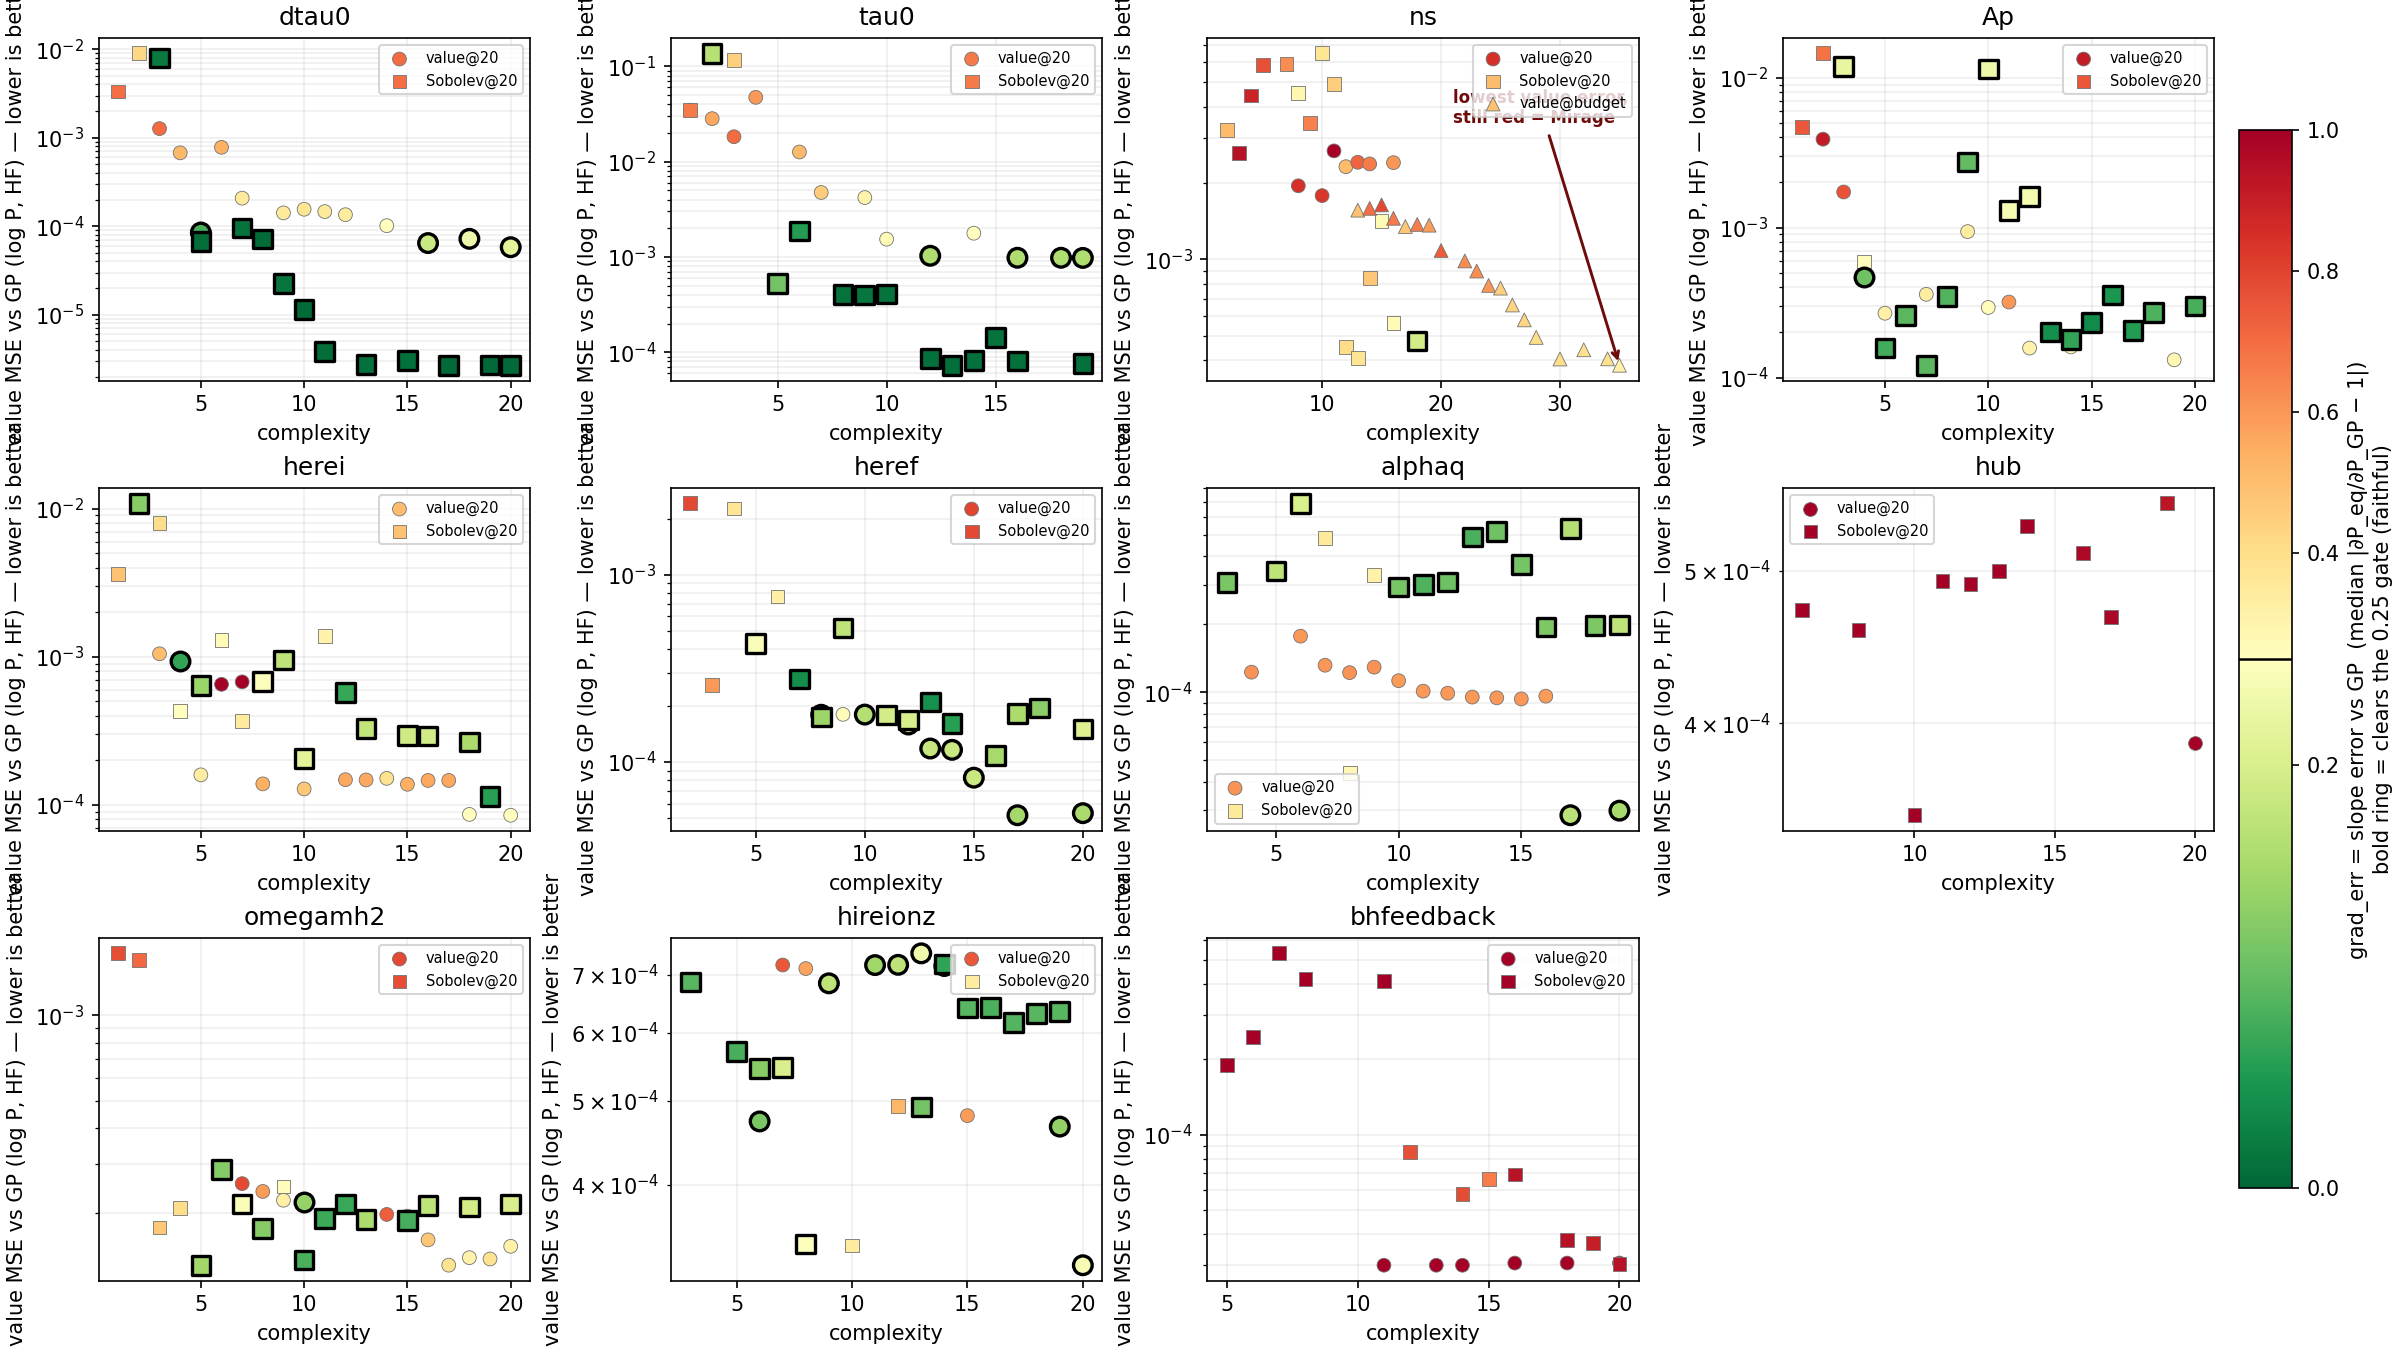

In [4]:
from IPython.display import Image, display
display(Image(filename=str(OUT / "pareto_faithfulness.png")))

## Figure 2 — `faithfulness_scorecard` (one-glance summary)

For each parameter, the `grad_err` of the **value-optimal** (lowest-loss) equation,
sorted by the Sobolev value: **value@20** ● (red) vs **Sobolev@20** ■ (green), with
the **0.25 gate** dashed. The two parameters that stay above the gate even under
Sobolev (**hub, bhfeedback**) are labelled "resists"; **ns** makes the biggest jump.

`grad_err` is clipped at 1.05 for the y-axis only (the sidecars keep the raw value).

**Feeds:** `VALUE`, `SOBOLEV` best-loss rows. Emulator-free.

In [5]:
rows = sorted(((p, bestloss(VALUE, p), bestloss(SOBOLEV, p)) for p in PARAM_NAMES),
              key=lambda r: r[2])
labels = [r[0] for r in rows]
val = [r[1] for r in rows]
sob = [r[2] for r in rows]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 4.4), layout="constrained")
for xi, v, s in zip(x, val, sob):
    ax.plot([xi, xi], [min(v, 1.05), min(s, 1.05)], color="0.8", lw=1, zorder=1)
ax.scatter(x, np.clip(val, 0, 1.05), s=80, marker="o", facecolor="#d6604d",
           edgecolor="k", lw=.5, zorder=3, label="value@20 (value-optimal eq)")
ax.scatter(x, np.clip(sob, 0, 1.05), s=80, marker="s", facecolor="#1a9850",
           edgecolor="k", lw=.5, zorder=3, label="Sobolev@20 (value-optimal eq)")
ax.axhline(GATE_TOL, color="k", ls="--", lw=1.2)
ax.text(0.2, GATE_TOL + 0.02, "gate 0.25", fontsize=9)
for xi, (p, v, s) in zip(x, rows):
    if s > GATE_TOL:  # the resisters: label both numbers
        ax.annotate(f"{s:.2f}", (xi, min(s, 1.05)), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=8, color="#1a9850",
                    fontweight="bold")
        ax.annotate("resists", (xi, min(s, 1.05)), textcoords="offset points",
                    xytext=(0, 19), ha="center", fontsize=8, color="#7f0000")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylabel("grad_err of value-optimal eq (clipped 1.05)")
ax.set_title("Per-parameter derivative faithfulness: value-loss vs Sobolev (z=3.6)")
ax.set_ylim(0, 1.12); ax.grid(axis="y", alpha=.25); ax.legend(loc="upper left", fontsize=9)
fig.savefig(OUT / "faithfulness_scorecard.pdf")
fig.savefig(OUT / "faithfulness_scorecard.png", dpi=150)
plt.close(fig)
print("wrote", OUT / "faithfulness_scorecard.png", "(+ .pdf)")

wrote results/single_z_stage_pareto_diag/faithfulness_scorecard.png (+ .pdf)


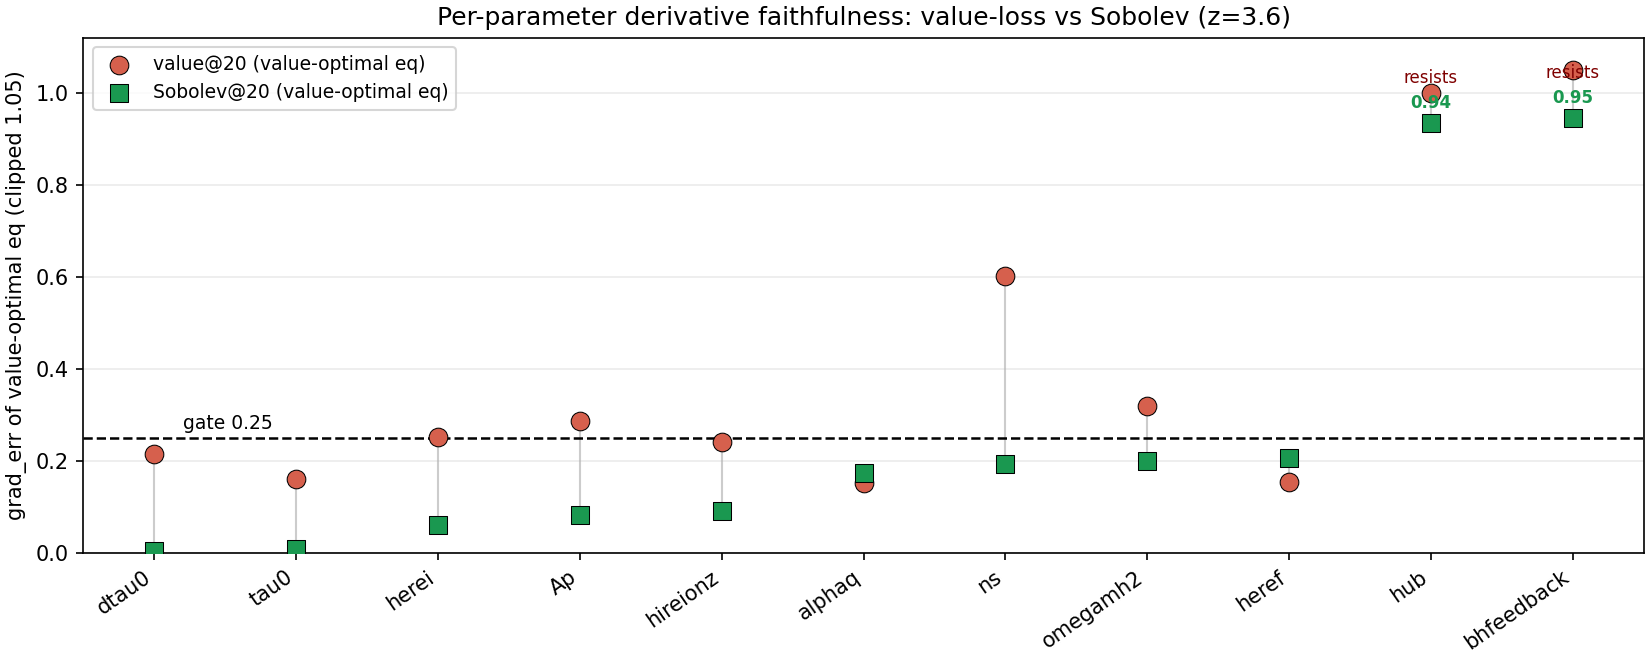

In [6]:
display(Image(filename=str(OUT / "faithfulness_scorecard.png")))

## Figure 3 — `ns_budget_panel` (the budget control)

The review's central objection was that "PySR can't" for **ns** might really be
"the search was starved" (the ladder ran maxsize 20). This panel reruns ns
value-loss at **maxsize ≈ 35** (▲) and overlays it with value@20 (●) and Sobolev@20
(■), colored by `grad_err`:

- **value@budget** reaches the *lowest* value error of any series — deeper search →
  better value fit — yet stays **red** (best-loss grad_err ≈ 0.32, **never** crosses
  the gate).
- **Sobolev@20** clears the gate (grad_err ≈ 0.19) at a *comparable, slightly higher*
  value error (~24% worse).

So the ns Mirage is **generative, not a budget shortfall**: you need the right
*objective*, not more search. Value accuracy and derivative faithfulness are
independent axes.

**Feeds:** `VALUE`, `BUDGET`, `SOBOLEV` ns sidecars. Emulator-free.

In [7]:
cmap = plt.get_cmap("RdYlGn_r")
norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=GATE_TOL, vmax=1.0)
fig, ax = plt.subplots(figsize=(7.8, 5.4), layout="constrained")
sc = None
for lab, d, mk in [("value@20", VALUE, "o"),
                   ("value@budget (maxsize 35)", BUDGET, "^"),
                   ("Sobolev@20", SOBOLEV, "s")]:
    df = read_grad_faith_sidecar(f"{d}/grad_faith_ns.csv")
    sc = ax.scatter(df["Complexity"], df["value_mse"], c=np.clip(df["grad_err"], 0, 1),
                    cmap=cmap, norm=norm, marker=mk, s=72, edgecolor="k", lw=.5, label=lab)
# Label the two load-bearing endpoints (best-loss of budget and Sobolev).
bdf = read_grad_faith_sidecar(f"{BUDGET}/grad_faith_ns.csv").sort_values("Loss").iloc[0]
sdf = read_grad_faith_sidecar(f"{SOBOLEV}/grad_faith_ns.csv").sort_values("Loss").iloc[0]
ax.annotate(f"budget: grad_err {bdf['grad_err']:.3f} FAIL\nvalue {bdf['value_mse']:.1e}",
            xy=(bdf["Complexity"], bdf["value_mse"]), xytext=(20, bdf["value_mse"] * 0.45),
            fontsize=8, color="#7f0000",
            arrowprops=dict(arrowstyle="->", color="#7f0000", lw=1.2))
ax.annotate(f"Sobolev: grad_err {sdf['grad_err']:.3f} PASS\nvalue {sdf['value_mse']:.1e}",
            xy=(sdf["Complexity"], sdf["value_mse"]), xytext=(7, sdf["value_mse"] * 2.6),
            fontsize=8, color="#1a9850",
            arrowprops=dict(arrowstyle="->", color="#1a9850", lw=1.2))
ax.set_yscale("log"); ax.set_xlabel("complexity")
ax.set_ylabel("value MSE vs GP (log P, HF) — lower is better")
ax.set_title("ns — budget reaches the lowest value error but never goes green;\n"
             "Sobolev clears the gate at a comparable (~24% higher) value error")
ax.grid(which="both", alpha=.25); ax.legend(loc="upper right", fontsize=9)
cb = fig.colorbar(sc, ax=ax); cb.set_label("grad_err (clipped 1)")
cb.ax.axhline(GATE_TOL, color="k", lw=1.2)
fig.savefig(OUT / "ns_budget_panel.pdf")
fig.savefig(OUT / "ns_budget_panel.png", dpi=150)
plt.close(fig)
print("wrote", OUT / "ns_budget_panel.png", "(+ .pdf)")

wrote results/single_z_stage_pareto_diag/ns_budget_panel.png (+ .pdf)


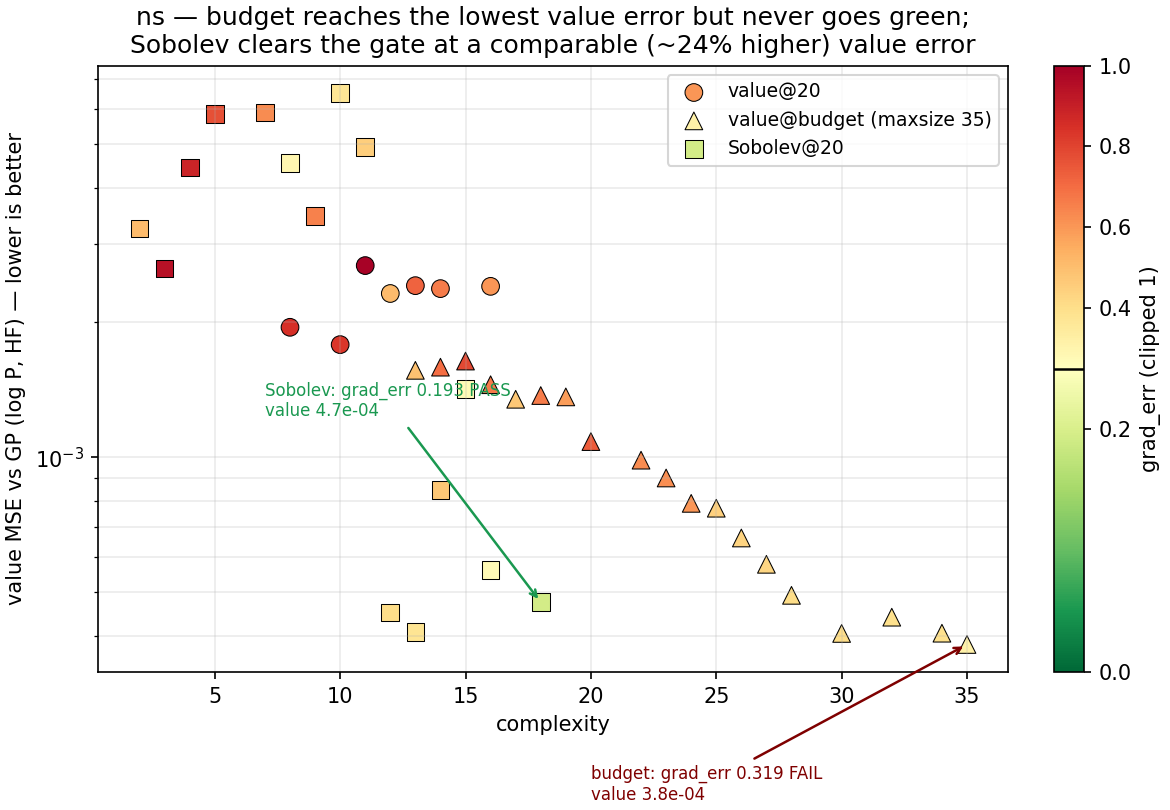

In [8]:
display(Image(filename=str(OUT / "ns_budget_panel.png")))

## Figure 4 — `crossz_faithfulness` (redshift robustness)

For each parameter, the **Sobolev best-loss `grad_err`** at z = 2.6 / 3.6 / 4.2,
with the 0.25 gate dashed (grad_err clipped at 1.2 for the y-axis). The z = 3.6
column is the same Sobolev refit used above (`single_z_stage9`); z = 2.6 / 4.2 are
**freshly retrained** Sobolev fits (not the z = 3.6 equations re-used), each
gate-evaluated.

**The taxonomy is NOT redshift-uniform.** Cosmology/mean-flux (dtau0, tau0, ns, Ap,
omegamh2) and the two resisters (hub, bhfeedback) are stable across z. The **He II
reionization block (herei, heref, alphaq) is faithful at z ≤ 3.6 and blows up at
z = 4.2** — their P1D imprint is redshift-localised, so away from their reion epoch
the GP slope is tiny and the gate cannot adjudicate. *Faithfulness tracks the
physics.* (Caveat: the GP is least accurate at z = 4.2, ~2% vs ~1% at z = 3.6, so
part of the z = 4.2 degradation is emulator-limited.)

**Feeds:** `single_z_z2.6_sobolev` (z=2.6), `single_z_stage9` (z=3.6),
`single_z_z4.2_sobolev` (z=4.2). Emulator-free.

In [9]:
CROSSZ = {
    "2.6": "results/single_z_z2.6_sobolev/refit/z2.6",
    "3.6": SOBOLEV,                                       # = single_z_stage9
    "4.2": "results/single_z_z4.2_sobolev/refit/z4.2",
}
ZVALS = [2.6, 3.6, 4.2]

# Confirm every cross-z sidecar is present (emulator-free).
for zk, d in CROSSZ.items():
    miss = [p for p in PARAM_NAMES if not (REPO_ROOT / d / f"grad_faith_{p}.csv").exists()]
    assert not miss, f"z={zk}: missing {miss}"
print("all cross-z Sobolev sidecars present.")

# Sobolev best-loss grad_err per (param, z).
table = {}
for p in PARAM_NAMES:
    table[p] = [bestloss(CROSSZ[f"{z}"], p) for z in ZVALS]

CLIP = 1.2
cmap20 = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
for i, p in enumerate(PARAM_NAMES):
    y = np.clip(table[p], 0, CLIP)
    ax.plot(ZVALS, y, marker="o", lw=1.8, ms=7, color=cmap20(i % 20), label=p)
ax.axhline(GATE_TOL, color="k", ls="--", lw=1.2)
ax.text(ZVALS[-1] - 0.05, GATE_TOL + 0.015, "gate 0.25", fontsize=9, ha="right")
ax.set_xticks(ZVALS); ax.set_xticklabels([f"{z}" for z in ZVALS])
ax.set_xlabel("redshift z")
ax.set_ylabel("Sobolev best-loss grad_err (clipped 1.2)")
ax.set_title("Redshift robustness of the derivative-faithfulness taxonomy (Sobolev fits)")
ax.set_ylim(-0.02, CLIP + 0.04); ax.grid(alpha=.25)
ax.legend(ncol=2, fontsize=9, loc="upper center")
fig.savefig(OUT / "crossz_faithfulness.pdf")
fig.savefig(OUT / "crossz_faithfulness.png", dpi=150)
plt.close(fig)
print("wrote", OUT / "crossz_faithfulness.png", "(+ .pdf)")

# Print the table (matches docs/PARETO_FAITHFULNESS_WALKTHROUGH.md).
print(f"\n{'param':11s} {'z=2.6':>7s} {'z=3.6':>7s} {'z=4.2':>7s}")
for p in PARAM_NAMES:
    v = table[p]
    print(f"{p:11s} {v[0]:7.3f} {v[1]:7.3f} {v[2]:7.3f}")

all cross-z Sobolev sidecars present.


wrote results/single_z_stage_pareto_diag/crossz_faithfulness.png (+ .pdf)

param         z=2.6   z=3.6   z=4.2
dtau0         0.004   0.003   0.008
tau0          0.006   0.009   0.010
ns            0.211   0.193   0.211
Ap            0.079   0.082   0.137
herei         0.186   0.060   0.709
heref         0.299   0.206   2.690
alphaq        0.097   0.173   1.556
hub           0.966   0.935   1.215
omegamh2      0.162   0.198   0.118
hireionz      0.324   0.090   0.203
bhfeedback    0.671   0.946   0.374


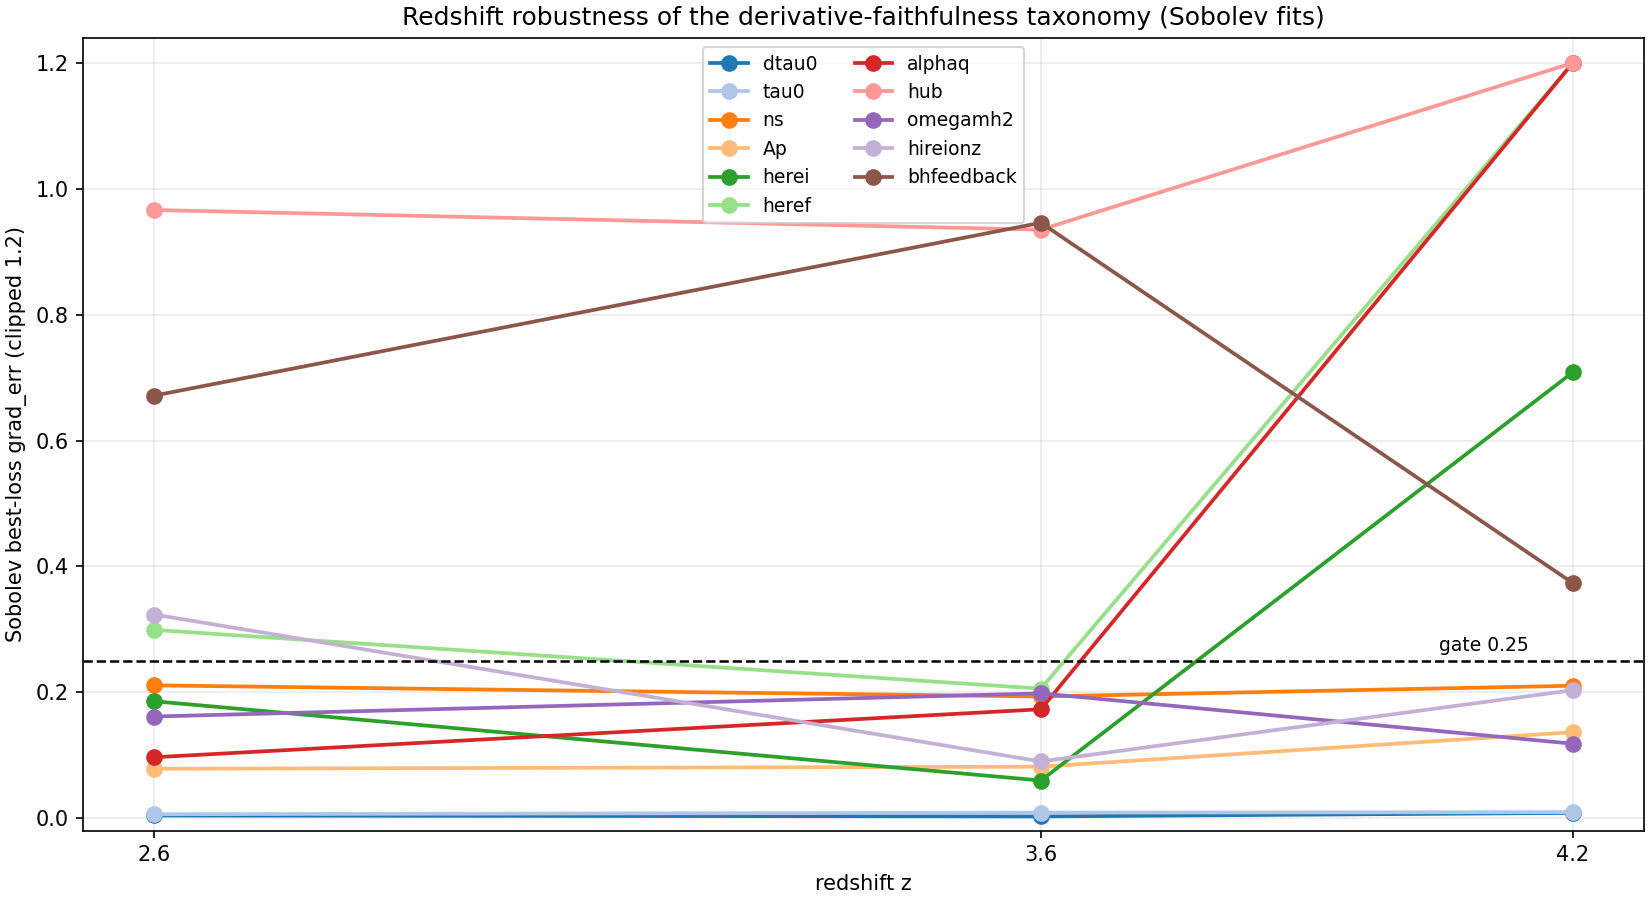

In [10]:
display(Image(filename=str(OUT / "crossz_faithfulness.png")))

## Confirm all four figures were produced

Final emulator-free check: assert the four PNG (+ PDF) artifacts exist on disk.

In [11]:
expected = ["pareto_faithfulness", "faithfulness_scorecard",
            "ns_budget_panel", "crossz_faithfulness"]
ok = True
for n in expected:
    for ext in ("png", "pdf"):
        f = OUT / f"{n}.{ext}"
        present = f.exists() and f.stat().st_size > 0
        ok = ok and present
        print(f"{'OK ' if present else 'MISS'}  {f}  ({f.stat().st_size if f.exists() else 0} bytes)")
assert ok, "one or more figures missing"
print("\nAll four diagnostic figures reproduced EMULATOR-FREE from the committed sidecars.")

OK   results/single_z_stage_pareto_diag/pareto_faithfulness.png  (296524 bytes)
OK   results/single_z_stage_pareto_diag/pareto_faithfulness.pdf  (61321 bytes)
OK   results/single_z_stage_pareto_diag/faithfulness_scorecard.png  (88145 bytes)
OK   results/single_z_stage_pareto_diag/faithfulness_scorecard.pdf  (21663 bytes)
OK   results/single_z_stage_pareto_diag/ns_budget_panel.png  (109449 bytes)
OK   results/single_z_stage_pareto_diag/ns_budget_panel.pdf  (25432 bytes)
OK   results/single_z_stage_pareto_diag/crossz_faithfulness.png  (161442 bytes)
OK   results/single_z_stage_pareto_diag/crossz_faithfulness.pdf  (21984 bytes)

All four diagnostic figures reproduced EMULATOR-FREE from the committed sidecars.
